# Cleopatra weather styles on **real** data

The ECMWF-derived `DATA_STYLES` weather presets, applied to genuine gridded fields:

- **temperature** styles on real **ERA5 2 m air temperature** (Europe), and
- **precipitation** styles on a real **NOAH land-model precipitation** raster, plus
- **flow accumulation** on a real hydrology raster.

Each preset is applied in one call with `ArrayGlyph(field, extent=..., ax=ax).plot(style=style, ...)`.

## Setup — imports

`ArrayGlyph` is cleopatra's array-plotting glyph. The
data is bundled as NumPy `.npz`, so nothing here reads GIS files — only `numpy` + `cleopatra`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cleopatra
from cleopatra.array_glyph import ArrayGlyph
print("cleopatra", cleopatra.__version__)

cleopatra 0.28.0


## Load the real fields

Three genuine gridded fields, each a NumPy `.npz` holding the array (or stack) and its
`[xmin, xmax, ymin, ymax]` extent:

- **ERA5 2 m temperature** — `day` picks the frame with the largest spread (`max - min`).
- **NOAH precipitation** and a **flow-accumulation** raster.

The `print` reports each field's shape and value range.

In [2]:
DATA = Path("../../../examples/data")   # kernel CWD is the notebook's own folder

def load(name):
    z = np.load(DATA / name)
    return z["array"].astype(float), [float(v) for v in z["extent"]]

z = np.load(DATA / "europe_t2m.npz", allow_pickle=True)
cel = z["celsius"]
day = int(np.argmax([np.nanmax(f) - np.nanmin(f) for f in cel]))   # most dynamic day
t2m = cel[day].astype(float)
t2m_ext = [float(v) for v in z["extent"]]
precip, precip_ext = load("noah_precip_europe.npz")
facc, facc_ext = load("flow_accumulation.npz")
print("t2m:", t2m.shape, "degC", (round(np.nanmin(t2m),1), round(np.nanmax(t2m),1)),
      "| precip:", precip.shape, (round(np.nanmin(precip),1), round(np.nanmax(precip),1)),
      "| flow_acc:", facc.shape)

t2m: (111, 164) degC (np.float64(-1.5), np.float64(35.5)) | precip: (25, 40) (np.float64(0.0), np.float64(28.8)) | flow_acc: (13, 14)


## A gallery helper

`gallery` lays out one field under many styles in a grid — one `ArrayGlyph(field, ax=ax).plot(style=...)`
per panel:

- `nrow` is derived from the style count and `ncol`.
- `gext` reorders the imshow extent to ArrayGlyph's `[xmin, ymin, xmax, ymax]` convention.
- each panel draws the field with one preset; `add_colorbar=False` keeps the grid clean and ticks are hidden.
- any unused trailing axes are hidden, and a bold `suptitle` labels the whole grid.

In [3]:
def gallery(styles, field, extent, title, ncol=3):
    styles = list(styles)
    nrow = int(np.ceil(len(styles) / ncol))
    # squeeze=False -> axes is always a 2-D array, so .ravel() works for any grid
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.3 * nrow), squeeze=False)
    gext = [extent[0], extent[2], extent[1], extent[3]]   # -> ArrayGlyph [xmin, ymin, xmax, ymax]
    for i, ax in enumerate(axes.ravel()):
        if i >= len(styles):
            ax.set_visible(False)                          # hide leftover empty panels
            continue
        glyph = ArrayGlyph(field, extent=gext, ax=ax)
        glyph.plot(style=styles[i], add_colorbar=False, title=styles[i], title_size=9)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    plt.show()

## Temperature styles — real ERA5 2 m temperature (°C, Europe)

These presets assume °C, which matches ERA5. The two `temperature_flame*` styles tie opacity to value
(hot glows, cool fades) — the CAMS aerosol technique recoloured for heat.

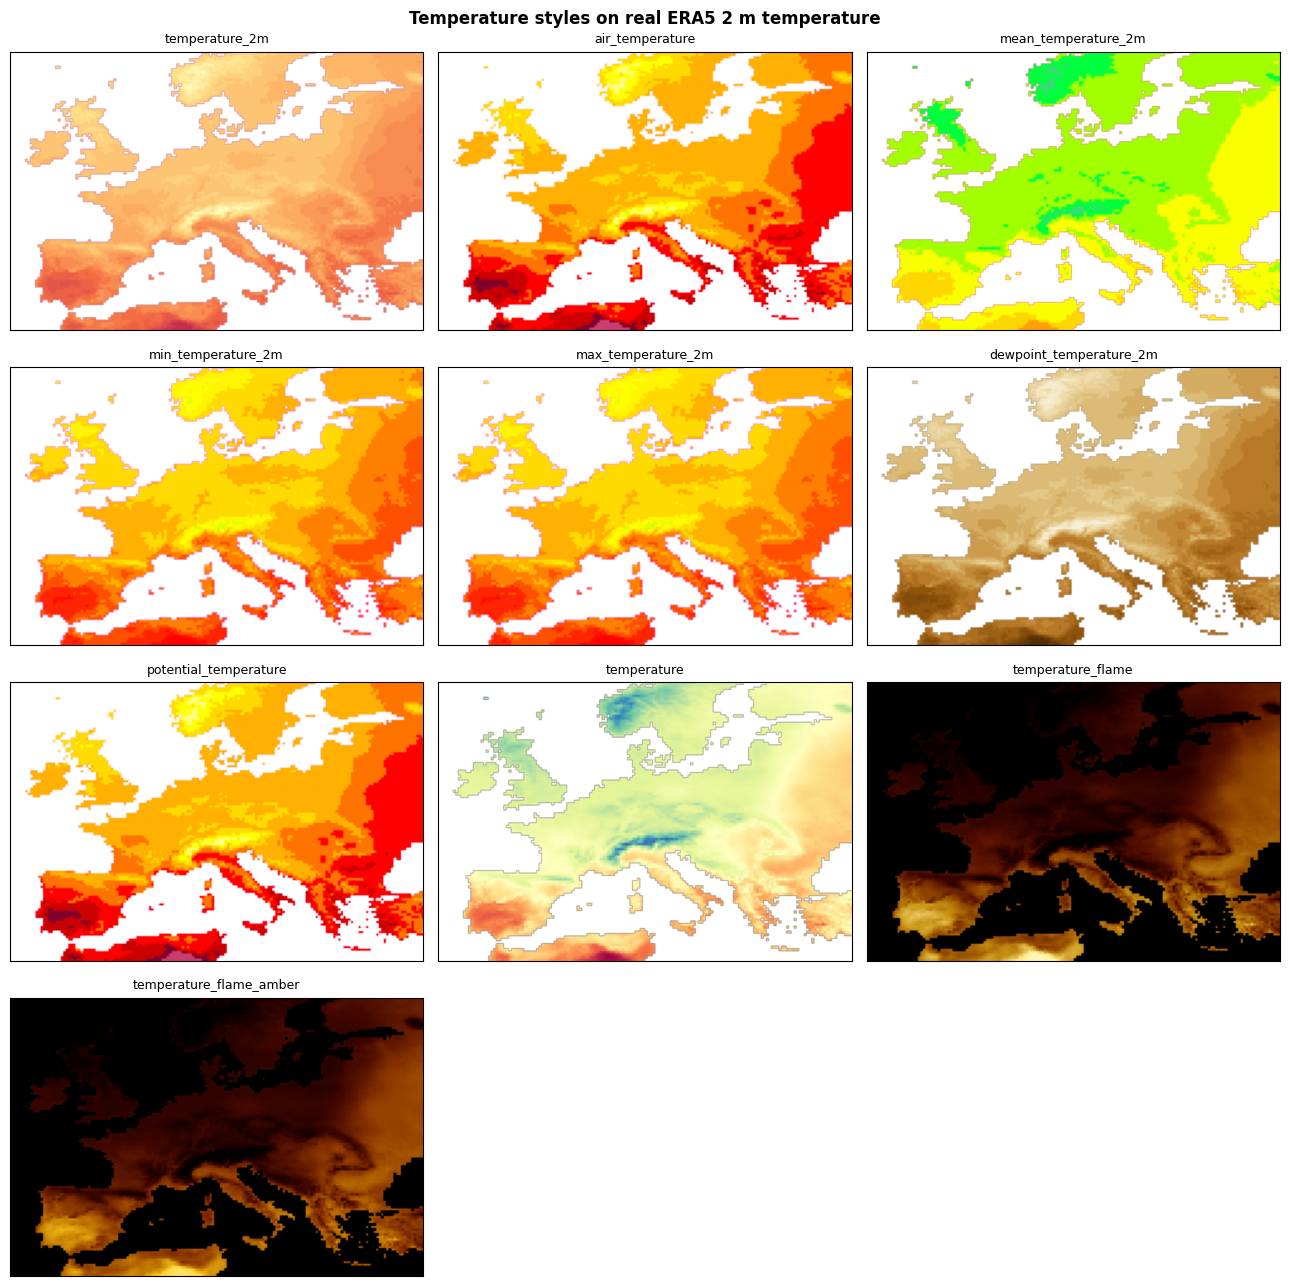

In [4]:
temp_styles = ["temperature_2m", "air_temperature", "mean_temperature_2m",
               "min_temperature_2m", "max_temperature_2m", "dewpoint_temperature_2m",
               "potential_temperature", "temperature", "temperature_flame", "temperature_flame_amber"]
gallery(temp_styles, t2m, t2m_ext, "Temperature styles on real ERA5 2 m temperature")

## Precipitation styles — real NOAH precipitation

The precipitation family (total / convective / large-scale precip, rain & snowfall rates) on a real
precipitation field.

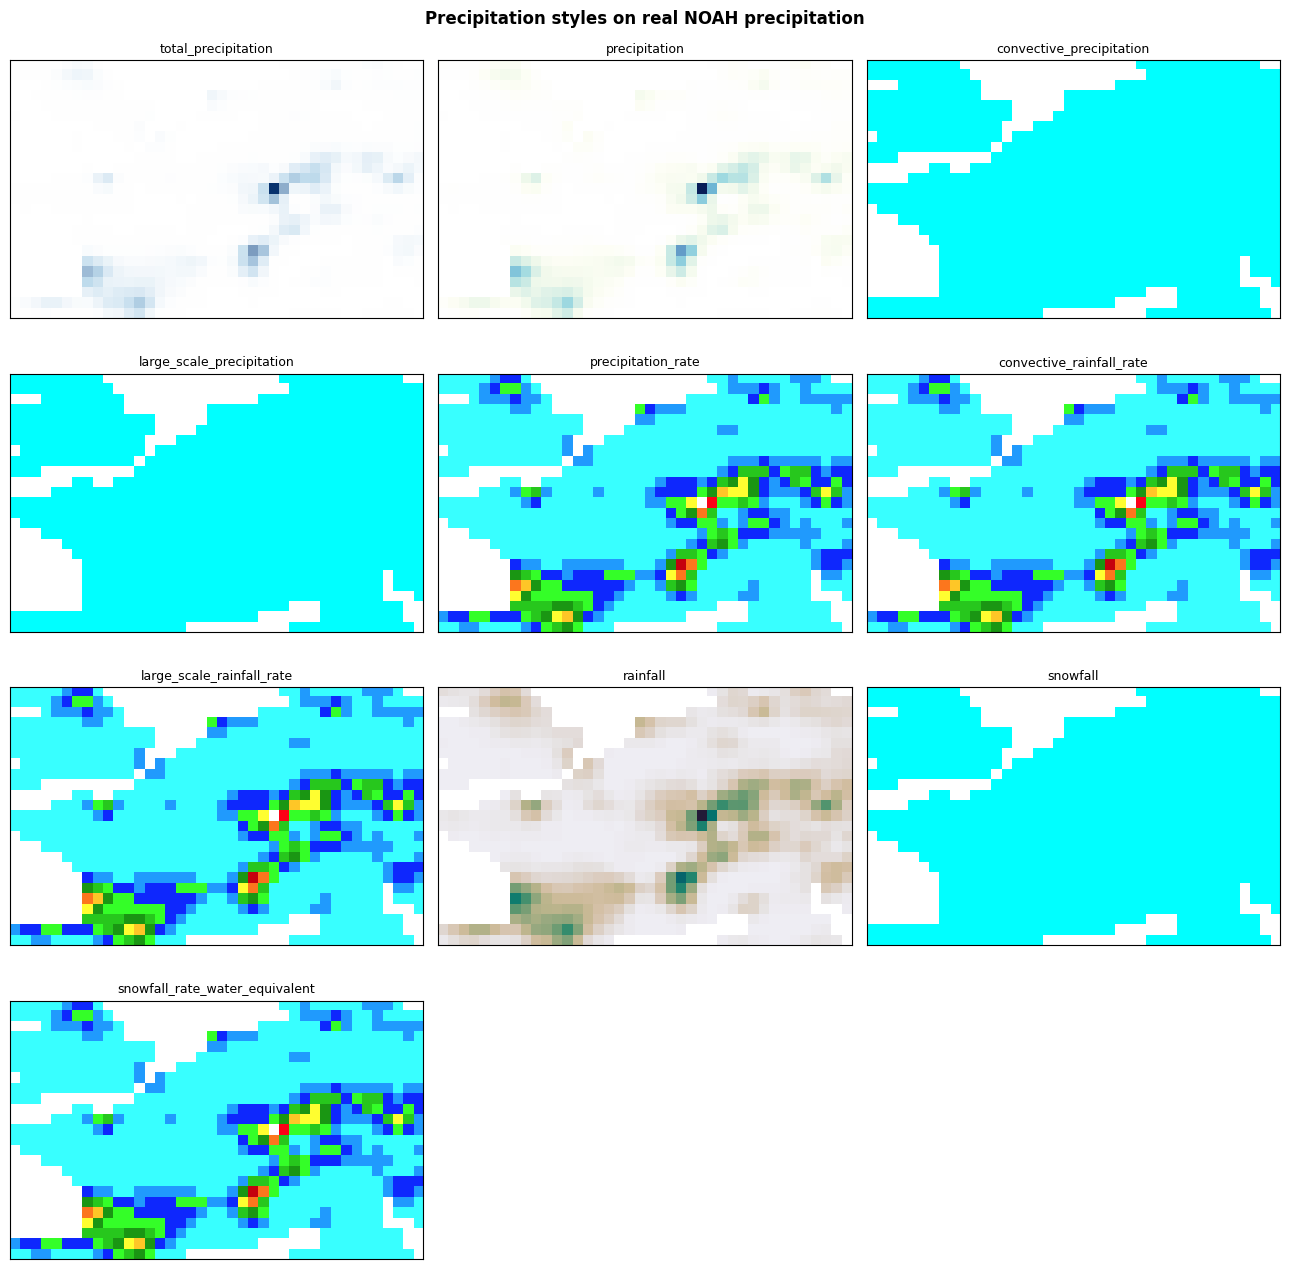

In [5]:
precip_styles = ["total_precipitation", "precipitation", "convective_precipitation",
                 "large_scale_precipitation", "precipitation_rate", "convective_rainfall_rate",
                 "large_scale_rainfall_rate", "rainfall", "snowfall", "snowfall_rate_water_equivalent"]
gallery(precip_styles, precip, precip_ext, "Precipitation styles on real NOAH precipitation")

## Flow accumulation — real hydrology raster

`flow_accumulation` uses a symmetric-log norm with value-linked opacity, so the channel network stands out
against faded low-accumulation cells.

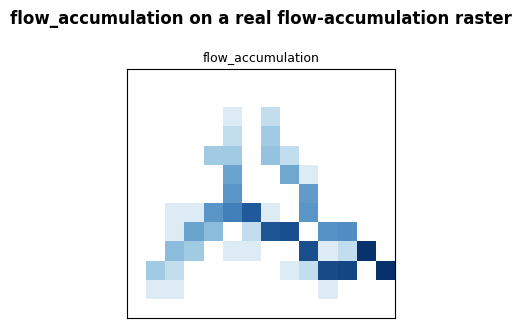

In [6]:
gallery(["flow_accumulation"], facc, facc_ext, "flow_accumulation on a real flow-accumulation raster", ncol=1)